# Load Datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

In [2]:
pdb_clusters = pd.read_csv('/fsimb/groups/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv', sep='\t')
cluster_summary = pd.read_csv("/fsimb/groups/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_cluster_summary.tsv", sep="\t")
cluster_lca = pd.read_csv("/fsimb/groups/imb-luckgr/projects/interface_clustering/results/cluster_analysis/cluster_lca.tsv", sep="\t", header=None)
cluster_lca.columns = ["rep","lca_id","lca_level","lca_name"]

/tmp/ipykernel_776244/1028200034.py:1: DtypeWarning: Columns (32,34) have mixed types. Specify dtype option on import or set low_memory=False.
  pdb_clusters = pd.read_csv('/fsimb/groups/imb-luckgr/projects/interface_clustering/results/cluster_analysis/pdb_clusters_annotated.tsv', sep='\t')


In [3]:
cluster_lca = pd.read_csv("/fsimb/groups/imb-luckgr/projects/interface_clustering/results/cluster_analysis/cluster_lca.tsv", sep="\t", header=None)
cluster_lca.columns = ["rep","lca_id","lca_level","lca_name"]

# Data Filteration and Candidate Mimicry Clusters

### Classification of Interface Clusters by Interaction Type

In [4]:
annot_only = pdb_clusters[((~pdb_clusters['tax_id_0'].isna()) & (~pdb_clusters['tax_id_1'].isna()))]
annot_only.loc[(annot_only['tax_id_0'] == annot_only['tax_id_1']), 'intraspecies'] = 1
annot_only.loc[(annot_only['tax_id_0'] != annot_only['tax_id_1']), 'intraspecies'] = 0
annot_only.loc[((annot_only['tax_id_0'] == 9606) | (annot_only['tax_id_1'] == 9606)), 'human'] = 1
annot_only['human'] = annot_only['human'].fillna(0)
annot_only.loc[((annot_only['human'] == 1) & (annot_only['intraspecies'] == 1)), "human-human"] = 1
annot_only['human-human'] = annot_only['human-human'].fillna(0)
annot_only.loc[((annot_only['human'] == 1) & (annot_only['intraspecies'] == 0)), "human-other"] = 1
annot_only['human-other'] = annot_only['human-other'].fillna(0)
annot_only.loc[((annot_only['human'] == 0) & (annot_only['intraspecies'] == 0) & (~annot_only['tax_id_0'].isna()) & (~annot_only['tax_id_1'].isna())), "other-other"] = 1
annot_only['other-other'] = annot_only['other-other'].fillna(0)
annot_only['counter'] = 1

search_mimicry = annot_only.groupby("intcluster")[['human-human','human-other','other-other','counter']].sum()
search_mimicry

/tmp/ipykernel_776244/2261107313.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annot_only.loc[(annot_only['tax_id_0'] == annot_only['tax_id_1']), 'intraspecies'] = 1
/tmp/ipykernel_776244/2261107313.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  annot_only.loc[((annot_only['tax_id_0'] == 9606) | (annot_only['tax_id_1'] == 9606)), 'human'] = 1
/tmp/ipykernel_776244/2261107313.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexe

,human-human,human-other,other-other,counter
intcluster,,,,
0,0.0,0.0,0.0,72
1,4.0,8.0,0.0,12
5,0.0,0.0,0.0,1
6,0.0,0.0,0.0,2
7,0.0,0.0,0.0,1
...,...,...,...,...
77162,0.0,2.0,0.0,2
77163,0.0,0.0,0.0,3
77164,0.0,0.0,0.0,1


### Find candidate mimicry clusters

In [5]:
humhum_humoth_cluster_ids = list(set(search_mimicry[((search_mimicry['human-human'] > 0) & (search_mimicry['human-other'] > 0))].index))
humhum_humoth_clusters = annot_only[((annot_only['intcluster'].isin(humhum_humoth_cluster_ids)) & (annot_only['human'] == 1))]
print("Number of clusters with human-human and human-other interactions: ", len(humhum_humoth_cluster_ids), f"({round(len(humhum_humoth_cluster_ids)/77167*100, 1)}% total clusters, {round(len(humhum_humoth_cluster_ids)/5699*100, 1)}% mixed clusters)")

Number of clusters with human-human and human-other interactions:  1302 (1.7% total clusters, 22.8% mixed clusters)


### Find which species interact with humans

In [6]:
human_interact_list = sorted(list(set(humhum_humoth_clusters['tax_id_0']) | set(humhum_humoth_clusters['tax_id_1'])))
print('[uid] OR '.join([str(int(x)) for x in human_interact_list])+'[uid]')
human_interact_list = pd.Series(human_interact_list)
human_interact_list.to_csv("human-human_human-other_interact_taxlist.tsv", sep="\t", index=False)

210[uid] OR 287[uid] OR 294[uid] OR 374[uid] OR 446[uid] OR 520[uid] OR 562[uid] OR 623[uid] OR 770[uid] OR 813[uid] OR 1117[uid] OR 1260[uid] OR 1280[uid] OR 1306[uid] OR 1311[uid] OR 1313[uid] OR 1314[uid] OR 1320[uid] OR 1338[uid] OR 1397[uid] OR 1406[uid] OR 1491[uid] OR 1502[uid] OR 1515[uid] OR 1762[uid] OR 1773[uid] OR 1836[uid] OR 1895[uid] OR 1931[uid] OR 2111[uid] OR 2261[uid] OR 2336[uid] OR 2702[uid] OR 3505[uid] OR 3649[uid] OR 3679[uid] OR 3702[uid] OR 3818[uid] OR 3847[uid] OR 4232[uid] OR 4565[uid] OR 4896[uid] OR 4932[uid] OR 5664[uid] OR 5671[uid] OR 5691[uid] OR 5693[uid] OR 5759[uid] OR 5762[uid] OR 5811[uid] OR 5833[uid] OR 6100[uid] OR 6182[uid] OR 6183[uid] OR 6239[uid] OR 6253[uid] OR 6334[uid] OR 6419[uid] OR 6421[uid] OR 6491[uid] OR 6715[uid] OR 6883[uid] OR 6943[uid] OR 7010[uid] OR 7070[uid] OR 7107[uid] OR 7108[uid] OR 7111[uid] OR 7130[uid] OR 7159[uid] OR 7165[uid] OR 7167[uid] OR 7227[uid] OR 7370[uid] OR 7757[uid] OR 7955[uid] OR 8017[uid] OR 8025[uid]

### Remove antybody and immune system related interactions

In [7]:
print("Number of interactions in the mimicry clusters involving at least one antibody: ", humhum_humoth_clusters[~humhum_humoth_clusters["antibody"].isna()].shape[0])
humhum_humoth_clusters = humhum_humoth_clusters[humhum_humoth_clusters["antibody"].isna()]

print("Number of interactions classified as 'IMMUNE SYSTEM': ", humhum_humoth_clusters[humhum_humoth_clusters["pdb_keyword"] == "IMMUNE SYSTEM"].shape[0])
humhum_humoth_clusters = humhum_humoth_clusters[humhum_humoth_clusters["pdb_keyword"] != "IMMUNE SYSTEM"]

Number of interactions in the mimicry clusters involving at least one antibody:  20036
Number of interactions classified as 'IMMUNE SYSTEM':  6151


### Drop Interactions involving Ecoli

In [8]:

with open("/fsimb/groups/imb-luckgr/projects/interface_clustering/datasets/cluster_analysis/e-coli_tax-id_list.txt", "r") as f:
    ecoli_tax_list = [int(x.strip("\n")) for x in f.readlines()]

mask = ((humhum_humoth_clusters["tax_id_0"].isin(ecoli_tax_list)) | (humhum_humoth_clusters["tax_id_1"].isin(ecoli_tax_list)))
print("Number of interactions in the mimicry clusters involving E. coli as the bacteria: ", humhum_humoth_clusters[mask].shape[0])
humhum_humoth_clusters = humhum_humoth_clusters[~mask]

Number of interactions in the mimicry clusters involving E. coli as the bacteria:  347


### Remove noisy clusters

In [9]:
noisy_cluster_ids = list(set(cluster_summary[cluster_summary["cluster_qtm"] < 0.5]["intcluster"]))
mask = humhum_humoth_clusters["intcluster"].isin(noisy_cluster_ids)
print("Number of interfaces in noisy clusters: ", humhum_humoth_clusters[mask].shape[0])
humhum_humoth_clusters = humhum_humoth_clusters[~mask]

print("Number of interfaces in mimicry clusters after filtering: ", humhum_humoth_clusters.shape[0])
print("Number of potential mimicry clusters left: ", humhum_humoth_clusters["intcluster"].nunique())

Number of interfaces in noisy clusters:  10598
Number of interfaces in mimicry clusters after filtering:  44446
Number of potential mimicry clusters left:  946


### Annotate human-pathogen interactions

In [10]:
humhum_humoth_tax_summary = pd.read_csv("/fsimb/groups/imb-luckgr/projects/interface_clustering/results/cluster_analysis/human-human_human-other_interact_summary.tsv", header=None, sep="\t")
humhum_humoth_tax_summary.columns = ["tax_id","tax_category"]
print(humhum_humoth_tax_summary["tax_category"].unique())

['Bacteria' 'Archaea' 'Eukaryota' 'mammalia' 'Homo' 'Homo sapiens'
 'Viruses' 'other entries' 'unclassified entries']


In [11]:
humhum_humoth_clusters["tax_category_0"] = humhum_humoth_clusters["tax_id_0"].map(dict(zip(humhum_humoth_tax_summary.tax_id, humhum_humoth_tax_summary.tax_category)))
humhum_humoth_clusters["tax_category_1"] = humhum_humoth_clusters["tax_id_1"].map(dict(zip(humhum_humoth_tax_summary.tax_id, humhum_humoth_tax_summary.tax_category)))
humhum_humoth_clusters.loc[((humhum_humoth_clusters["human-other"] == 1) & ((humhum_humoth_clusters["tax_category_0"] == "Bacteria") | (humhum_humoth_clusters["tax_category_0"] == "Viruses"))), "human-pathogen"] = 1
humhum_humoth_clusters.loc[((humhum_humoth_clusters["human-other"] == 1) & ((humhum_humoth_clusters["tax_category_1"] == "Bacteria") | (humhum_humoth_clusters["tax_category_1"] == "Viruses"))), "human-pathogen"] = 1
humhum_humoth_clusters.loc[((humhum_humoth_clusters["human-other"] == 1) & (humhum_humoth_clusters["tax_category_0"] == "Bacteria")), "pathogen_type"] = "Bacteria"
humhum_humoth_clusters.loc[((humhum_humoth_clusters["human-other"] == 1) & (humhum_humoth_clusters["tax_category_0"] == "Viruses")), "pathogen_type"] = "Virus"
humhum_humoth_clusters.loc[((humhum_humoth_clusters["human-other"] == 1) & (humhum_humoth_clusters["tax_category_1"] == "Bacteria")), "pathogen_type"] = "Bacteria"
humhum_humoth_clusters.loc[((humhum_humoth_clusters["human-other"] == 1) & (humhum_humoth_clusters["tax_category_1"] == "Viruses")), "pathogen_type"] = "Virus"

### Identify clusters with at least one human-human and one human-pathogen interaction

In [12]:
humhum_humoth_cluster_search_path = humhum_humoth_clusters.groupby("intcluster")[["human-human","human-pathogen"]].describe()
mask = ((humhum_humoth_cluster_search_path[('human-human','max')] == 1) & (humhum_humoth_cluster_search_path[('human-pathogen','max')] == 1))
humhum_humoth_path_clusters = list(set(humhum_humoth_cluster_search_path[mask].index))
print(len(humhum_humoth_path_clusters))
print(humhum_humoth_path_clusters)

143
[15361, 33290, 68619, 50189, 72206, 11283, 27669, 13849, 50717, 2605, 15408, 7729, 23089, 13365, 39990, 39991, 33852, 69693, 66628, 42567, 73800, 33353, 33355, 7757, 15950, 58449, 67160, 33375, 32357, 53863, 28264, 58984, 64616, 18029, 26223, 75888, 24179, 42612, 39549, 76938, 33936, 57498, 8348, 7837, 32423, 15530, 74930, 56505, 35002, 61115, 26301, 27846, 9928, 50893, 14030, 28879, 32483, 66787, 5351, 57063, 46313, 14058, 70888, 14061, 69360, 5368, 15097, 249, 15098, 64762, 19197, 9471, 35076, 5382, 29960, 33035, 12557, 25362, 36631, 57113, 56090, 70951, 63280, 26418, 76084, 13626, 5956, 34119, 39243, 14159, 22864, 5973, 17237, 4441, 47450, 21343, 71009, 2917, 2918, 74597, 58729, 57716, 71540, 27518, 27519, 19840, 66946, 31107, 76675, 34693, 29578, 34705, 74645, 25499, 44447, 56746, 23979, 65451, 4013, 38830, 70572, 22960, 55223, 13245, 38342, 13256, 3023, 55767, 40921, 22491, 45538, 20455, 50666, 19950, 67566, 9714, 2035, 22004, 35828, 24054, 57847, 5625, 58875]


# Human-Pathogen Mimicry Clusters' Summary

### Classify Interfaces

In [13]:

df = humhum_humoth_clusters.copy()
print(f"Total clusters in Human-Human and Human-Other dataset: {len(sorted(df['intcluster'].dropna().unique()))}")


conditions = [

    df["human-human"] == 1,
    (df["human-pathogen"] == 1) &
    (df["pathogen_type"] == "Bacteria"),
    (df["human-pathogen"] == 1) &
    (df["pathogen_type"] == "Virus"),
    (df["human-human"] == 0) &
    (df["human-pathogen"].isna()) &
    (df["pathogen_type"].isna())
]

choices = [
    "Human-Human",
    "Human-Bacteria",
    "Human-Virus",
    "Human-Other"
]

df["interface_type"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

print("Distribution of Interface in human-human and human-other dataset")
df["interface_type"].value_counts()

Total clusters in Human-Human and Human-Other dataset: 946
Distribution of Interface in human-human and human-other dataset


interface_type
Human-Human       35824
Human-Other        7023
Human-Virus        1367
Human-Bacteria      232
Name: count, dtype: int64

### Classify Pathogen Specific Clusters

In [14]:
cluster_presence = (df.groupby(["intcluster","interface_type"]).size().unstack(fill_value=0))
presence = cluster_presence > 0

### Bacterial Mimicry Clusters
mimicry_clusters_bacteria = presence[
    (presence["Human-Human"]) &
    (presence["Human-Bacteria"]) &
    (~presence["Human-Virus"])
].index.tolist()

### Viral Mimicry Clusters
mimicry_clusters_virus = presence[
    (presence["Human-Human"]) &
    (presence["Human-Virus"]) &
    (~presence["Human-Bacteria"])
].index.tolist()

### Virus-Bacteria Mimicry Clusters
mimicry_clusters_virus_bacteria = presence[
    (presence["Human-Human"]) &
    (presence["Human-Bacteria"]) &
    (presence["Human-Virus"])
].index.tolist()

### Human-Human clusters 
human_human_clusters_hh_ho_dataset = presence[
    (presence["Human-Human"]) &
    (~presence["Human-Bacteria"]) &
    (~presence["Human-Virus"]) &
    (~presence["Human-Other"])
].index.tolist()

### Mimicry clusters Other
mimicry_clusters_other = presence[
    (presence["Human-Human"]) &
    (~presence["Human-Bacteria"]) &
    (~presence["Human-Virus"]) &
    (presence["Human-Other"])
].index.tolist()

### Non-mimicry clusters
all_clusters = set(df["intcluster"].dropna().unique()) # PDB Cluster dataset (complete dataset)
mimicry_clusters_set = set(mimicry_clusters_bacteria + mimicry_clusters_virus + mimicry_clusters_virus_bacteria)
non_mimicry_clusters = sorted(all_clusters - mimicry_clusters_set)

###Summary : Mimicry & Non-mimicry clusters
summary = pd.DataFrame({
    "Category":[
        "Total clusters in Pdb_clusters dataset",
        "Total clusters in humhum_humoth_clusters dataset",
        "Total non-mimicry Human clusters",
        "Bacterial mimicry clusters",
        "Viral mimicry clusters",
        "Virus-Bacteria mimicry clusters",
        "Other mimicry clusters",
        "Human-Human cluster in humhum-humoth clusters dataset"
    ],
    "Count":[
        len(pdb_clusters["intcluster"].dropna().unique()),
        len(sorted(df['intcluster'].dropna().unique())),
        len(non_mimicry_clusters),
        len(mimicry_clusters_bacteria),
        len(mimicry_clusters_virus),
        len(mimicry_clusters_virus_bacteria),
        len(mimicry_clusters_other),
        len(human_human_clusters_hh_ho_dataset)
    ]
})

summary

,Category,Count
0,Total clusters in Pdb_clusters dataset,77167
1,Total clusters in humhum_humoth_clusters dataset,946
2,Total non-mimicry Human clusters,803
3,Bacterial mimicry clusters,36
4,Viral mimicry clusters,101
5,Virus-Bacteria mimicry clusters,6
6,Other mimicry clusters,662
7,Human-Human cluster in humhum-humoth clusters ...,112


# UniProt Annotation

### Get UniProt IDs from Dataset

In [15]:
# Extract UniProt IDs from interface dataset
uniprot_series = humhum_humoth_clusters["uniprot_ids"]
uniprot_list = []

for entry in uniprot_series.dropna():
    entry = str(entry) 
    ids = entry.split("-") 
    for uid in ids:
        if uid.lower() in ["nan", "none", ""]:
            continue

        uniprot_list.append(uid.strip())


# Unique UniProt IDs
unique_uniprot_ids = sorted(set(uniprot_list))
print("Total unique UniProt IDs:", len(unique_uniprot_ids))

uniprot_df = pd.DataFrame(unique_uniprot_ids, columns=["UniProt_ID"])
uniprot_df.to_csv("unique_uniprot_ids.csv", index=False)
print("Saved: unique_uniprot_ids.csv")

Total unique UniProt IDs: 3490
Saved: unique_uniprot_ids.csv


### Annotate Human-Pathogen Interfaces

In [16]:
import pandas as pd
import numpy as np


# Load UniProt annotation table 
uniprot_map = pd.read_csv("idmapping_2026_07_20.tsv", sep="\t", dtype=str, keep_default_na=False, encoding="utf-8-sig")
uniprot_map.columns = (uniprot_map.columns.str.strip().str.replace("\ufeff", "", regex=False))


# Build lookup dictionary
lookup = {}

for _, row in uniprot_map.iterrows():
    uid = row["From"].strip()
    gene = row["Gene Names (primary)"].strip() 

    if gene == "":
        gene = uid

    lookup[uid] = {"gene": gene, "organism": row["Organism"].strip(), "taxid": row["Organism (ID)"].strip()}

# Copy dataset
annotated_df = humhum_humoth_clusters.copy()

# Create new columns
new_columns = [
    "uniprot_human",
    "uniprot_pathogen",
    "gene_human",
    "gene_pathogen",
    "organism_pathogen",
    "organism_id_pathogen"
]

for c in new_columns:
    annotated_df[c] = ""

# Process only human-pathogen interfaces
for idx, row in annotated_df.iterrows():
    
    if pd.isna(row["human-pathogen"]): 
        continue

    # Read UniProt IDs
    value = row["uniprot_ids"]
    if pd.isna(value):
        continue

    ids = [
        x.strip()
        for x in str(value).split("-")
        if x.strip().lower() not in ["", "nan", "none"]
    ]

    if len(ids) == 0:
        continue

    # Tax IDs of interaction partners
    tax0 = str(row["tax_id_0"]).split(".")[0]
    tax1 = str(row["tax_id_1"]).split(".")[0]

    # Assign each UniProt
    for uid in ids:

        if uid not in lookup:
            continue

        info = lookup[uid]
        org_tax = info["taxid"]
        gene = info["gene"]
        organism = info["organism"]

        # Match against partner 0
        if org_tax == tax0:
            if tax0 == "9606":
                annotated_df.at[idx, "uniprot_human"] = uid
                annotated_df.at[idx, "gene_human"] = gene

            else:
                annotated_df.at[idx, "uniprot_pathogen"] = uid
                annotated_df.at[idx, "gene_pathogen"] = gene
                annotated_df.at[idx, "organism_pathogen"] = organism
                annotated_df.at[idx, "organism_id_pathogen"] = org_tax

        # Match against partner 1
        elif org_tax == tax1:
            if tax1 == "9606":
                annotated_df.at[idx, "uniprot_human"] = uid
                annotated_df.at[idx, "gene_human"] = gene

            else:
                annotated_df.at[idx, "uniprot_pathogen"] = uid
                annotated_df.at[idx, "gene_pathogen"] = gene
                annotated_df.at[idx, "organism_pathogen"] = organism
                annotated_df.at[idx, "organism_id_pathogen"] = org_tax


# Summary
print("Finished annotation.\n")
print("Human UniProt assigned:", (annotated_df["uniprot_human"] != "").sum())
print("Pathogen UniProt assigned:", (annotated_df["uniprot_pathogen"] != "").sum())
print("Human genes assigned:", (annotated_df["gene_human"] != "").sum())
print("Pathogen genes assigned:", (annotated_df["gene_pathogen"] != "").sum())

Finished annotation.

Human UniProt assigned: 1462
Pathogen UniProt assigned: 809
Human genes assigned: 1462
Pathogen genes assigned: 809


### Annotate Human-Human, Huamn-Virus and Human-Bacteria Pair 

In [17]:
# Load UniProt annotation table
uniprot_map = pd.read_csv("idmapping_2026_07_20.tsv", sep="\t", dtype=str, keep_default_na=False, encoding="utf-8-sig" )

# Remove duplicates (keep first occurrence)
uniprot2gene = (uniprot_map[["From", "Gene Names (primary)"]].drop_duplicates(subset="From").set_index("From")["Gene Names (primary)"].to_dict())

# Create new columns
new_cols = [
    "human_human_genes",
    "human_virus_genes",
    "human_bacteria_genes",
    "human_human_uniprot",
    "human_virus_uniprot",
    "human_bacteria_uniprot",
]

for col in new_cols:
    annotated_df[col] = pd.NA

# Helper functions
def clean_value(x):
    """Convert empty/NaN to 'NA'."""
    if pd.isna(x):
        return "NA"
    x = str(x).strip()
    return x if x else "NA"


def split_uniprots(val):
    """
    Returns two UniProt IDs.
    Handles:
        P12345-Q99999
        P12345
        -
        ''
        NaN
    """
    if pd.isna(val):
        return "NA", "NA"

    val = str(val).strip()

    if val == "":
        return "NA", "NA"

    parts = val.split("-", 1)

    if len(parts) == 1:
        return clean_value(parts[0]), "NA"

    return clean_value(parts[0]), clean_value(parts[1])


# Human-Human annotations
hh_mask = annotated_df["human-human"] == 1

for idx in annotated_df.index[hh_mask]:
    u1, u2 = split_uniprots(annotated_df.at[idx, "uniprot_ids"])
    g1 = uniprot2gene.get(u1, "")
    g2 = uniprot2gene.get(u2, "")
    g1 = g1 if g1 else "NA"
    g2 = g2 if g2 else "NA"
    annotated_df.at[idx, "human_human_uniprot"] = f"{u1}-{u2}"
    annotated_df.at[idx, "human_human_genes"] = f"{g1}-{g2}"


# Human-Virus annotations
virus_mask = annotated_df["pathogen_type"].eq("Virus")
annotated_df.loc[virus_mask, "human_virus_uniprot"] = (annotated_df.loc[virus_mask, "uniprot_human"].apply(clean_value) + "-" + annotated_df.loc[virus_mask, "uniprot_pathogen"].apply(clean_value))
annotated_df.loc[virus_mask, "human_virus_genes"] = (annotated_df.loc[virus_mask, "gene_human"].apply(clean_value) + "-" + annotated_df.loc[virus_mask, "gene_pathogen"].apply(clean_value))

# Human-Bacteria annotations
bacteria_mask = annotated_df["pathogen_type"].eq("Bacteria")
annotated_df.loc[bacteria_mask, "human_bacteria_uniprot"] = (annotated_df.loc[bacteria_mask, "uniprot_human"].apply(clean_value) + "-" + annotated_df.loc[bacteria_mask, "uniprot_pathogen"].apply(clean_value))
annotated_df.loc[bacteria_mask, "human_bacteria_genes"] = (annotated_df.loc[bacteria_mask, "gene_human"].apply(clean_value) + "-" + annotated_df.loc[bacteria_mask, "gene_pathogen"].apply(clean_value))

# Pfam Annotation at Interface

In [18]:
res_map = pd.read_csv('/fsimb/groups/imb-luckgr/projects/interface_clustering/datasets/cluster_analysis/mapping/uniprot_residue_mapping.tsv', sep='\t')

In [19]:
import pandas as pd
import numpy as np

# 1. Read Pfam annotations
pfam = pd.read_csv("/fsimb/groups/imb-luckgr/projects/interface_clustering/datasets/cluster_analysis/mapping/pdb_pfam.tsv", sep="\t")

# 2. Merge with residue mapping (same as original)
res_map_pluspfam = pd.merge(res_map, pfam, on=["pdb_id", "chain_id"], how="left")

# 3. Keep only Pfam domains overlapping interface residues
def check_pfam_range(r):

    if pd.isna(r["start"]) or pd.isna(r["end"]):
        return 0

    if pd.isna(r["if_res"]):
        return 0

    full_range = range(int(r["start"]), int(r["end"]) + 1)

    for ifres in map(int, str(r["if_res"]).split(",")):
        if ifres in full_range:
            return 1

    return 0

res_map_pluspfam["pfam_in_range"] = (res_map_pluspfam.apply(check_pfam_range, axis=1))

# 4. Remove non-interface Pfams (same as original)
res_map_pluspfam.loc[res_map_pluspfam["pfam_in_range"] == 0, "pfam_name"] = None
res_map_pluspfam.loc[res_map_pluspfam["pfam_in_range"] == 0, "pfam_id"] = None

# 5. Remove duplicate Pfam annotations per interface partner
res_map_pluspfam = res_map_pluspfam.drop_duplicates(subset=["full_id", "pfam_id"], keep="first")

# 6. Collect Pfam annotations for each interface partner (full_id)
def get_pfam_list(x):
    vals = sorted(set(y for y in x["pfam_name"] if pd.notna(y) and y != ""))
    return ",".join(vals)

pfam_partner = (res_map_pluspfam.groupby(["new_complex_id", "full_id"]).apply(get_pfam_list, include_groups=False).reset_index(name="pfam"))

# 7. Recover chain_id for each full_id
partner_ids = (res_map[["new_complex_id", "full_id", "chain_id"]].drop_duplicates())
pfam_partner = pfam_partner.merge(partner_ids, on=["new_complex_id", "full_id"], how="left")

# 8. One Pfam annotation per chain within each interface
chain_pfam = (pfam_partner.groupby(["new_complex_id", "chain_id"])["pfam"].apply(lambda x: ",".join(sorted(set(y for y in x if y != "")))).reset_index())

# 9. Lookup dictionary
lookup = dict(zip(zip(chain_pfam["new_complex_id"], chain_pfam["chain_id"]), chain_pfam["pfam"]))

# 10. Annotate interface partners
annotated_df["pfam_0"] = annotated_df.apply(lambda r: lookup.get((r["new_complex_id"], str(r["chain_id_0"]).split("-")[0]), ""), axis=1)
annotated_df["pfam_1"] = annotated_df.apply(lambda r: lookup.get((r["new_complex_id"], str(r["chain_id_1"]).split("-")[0]), ""), axis=1)

print("Annotation Completed")

Annotation Completed


# Refine Mimicry Cluster Sets

Filter out clusters involving chimeric, synthetic, modified, or multi-mutated protein chains based on UniProt annotations.

### Refine Bacterial Mimicry Cluster Set

In [20]:
import pandas as pd

def valid_pair(pair):
    """Return True only if both UniProt IDs are present."""
    if pd.isna(pair):
        return False

    pair = str(pair).strip()

    if pair == "":
        return False

    parts = pair.split("-", 1)

    if len(parts) != 2:
        return False

    return all(
        p.strip().upper() not in {"", "NA", "NAN"}
        for p in parts
    )


temp_dfhb = annotated_df[annotated_df["intcluster"].isin(mimicry_clusters_bacteria)].copy()

# Keep only rows with complete UniProt pair annotation
temp_dfhb = temp_dfhb[
    ((temp_dfhb["human-human"] == 1) & temp_dfhb["human_human_uniprot"].apply(valid_pair)) |
    ((temp_dfhb["pathogen_type"] == "Virus") & temp_dfhb["human_virus_uniprot"].apply(valid_pair)) |
    ((temp_dfhb["pathogen_type"] == "Bacteria") & temp_dfhb["human_bacteria_uniprot"].apply(valid_pair))
]

# ---------------------------------------------------------
# Keep only clusters having BOTH:
#   - at least one valid human-human interaction
#   - at least one valid human-bacteria interaction
# ---------------------------------------------------------

valid_clusters = []

for cluster, grp in temp_dfhb.groupby("intcluster"):
    has_hh = ((grp["human-human"] == 1) & grp["human_human_uniprot"].apply(valid_pair)).any()
    has_bacteria = ((grp["pathogen_type"] == "Bacteria") & grp["human_bacteria_uniprot"].apply(valid_pair)).any()

    if has_hh and has_bacteria:
        valid_clusters.append(cluster)

temp_dfhb = temp_dfhb[temp_dfhb["intcluster"].isin(valid_clusters)]
temp_dfhb.to_csv("Mimicry_human_bacteria_clusters.csv", index=False)

### Cluster Summary : Bacterial Mimicry

In [21]:
import pandas as pd

# Split dataframe
pathogen_df = temp_dfhb[temp_dfhb["pathogen_type"].isin(["Bacteria", "Virus"])].copy()
hh_df = temp_dfhb[temp_dfhb["human-human"] == 1].copy()
clusters = sorted(temp_dfhb["intcluster"].dropna().unique())
records = []

# Helper
def unique_pairs(series):
    vals = (series.fillna("").astype(str).str.strip())
    vals = vals[(~vals.isin(["", "NA", "NA-NA"]))]
    return sorted(vals.unique())

# Cluster summary
for cluster in clusters:
    tmp = pathogen_df[pathogen_df["intcluster"] == cluster]
    bac = tmp[tmp["pathogen_type"] == "Bacteria"]
    vir = tmp[tmp["pathogen_type"] == "Virus"]
    hh = hh_df[hh_df["intcluster"] == cluster]

    # Human-human proteins/interactions
    hh_gene_pairs = unique_pairs(hh["human_human_genes"])
    hh_uniprot_pairs = unique_pairs(hh["human_human_uniprot"])
    human_genes = set()
    human_uniprots = set()

    for pair in hh_gene_pairs:
        human_genes.update(x.strip() for x in pair.split("-") if x.strip() != "NA")

    for pair in hh_uniprot_pairs:
        human_uniprots.update(x.strip() for x in pair.split("-") if x.strip() != "NA")

    # Human-pathogen interaction pairs
    human_bacteria_pairs = unique_pairs(bac["human_bacteria_genes"])
    human_bacteria_uniprots = unique_pairs(bac["human_bacteria_uniprot"])
    human_virus_pairs = unique_pairs(vir["human_virus_genes"])
    human_virus_uniprots = unique_pairs(vir["human_virus_uniprot"])

    # Record
    records.append({

        "Interface_cluster": cluster,

        # Human-human
        "HH_interfaces": len(hh),
        "Human_proteins": "; ".join(sorted(human_genes)),
        "No_human_proteins": len(human_genes),
        "Human_UniProt": "; ".join(sorted(human_uniprots)),
        "Human_interactions": "; ".join(hh_gene_pairs),
        "No_human_interactions": len(hh_gene_pairs),
        "Human_PDBs": "; ".join(sorted(hh["pdb_id"].dropna().unique())),

        # Human targets
        "No_human_targets": tmp["gene_human"].replace("", pd.NA).dropna().nunique(),
        "Human_targets": "; ".join(sorted(tmp["gene_human"].replace("", pd.NA).dropna().unique())),
        "Human_target_UniProt": "; ".join(sorted(tmp["uniprot_human"].replace("", pd.NA).dropna().unique())),

        # Bacteria
        "Bacterial_interfaces": len(bac),
        "Bacterial_clusters": bac["intcluster"].nunique(),
        "No_bacterial_species": bac["organism_pathogen"].replace("", pd.NA).dropna().nunique(),
        "Bacterial_species": "; ".join(sorted(bac["organism_pathogen"].replace("", pd.NA).dropna().unique())),
        "Bacterial_genes": "; ".join(sorted(bac["gene_pathogen"].replace("", pd.NA).dropna().unique())),
        "Bacterial_proteins": "; ".join(sorted(bac["uniprot_pathogen"].replace("", pd.NA).dropna().unique())),
        "Human_Bacteria_Interactions": "; ".join(human_bacteria_pairs),
        "Human_Bacteria_UniProt": "; ".join(human_bacteria_uniprots),
        "Bacterial_PDBs": "; ".join(sorted(bac["pdb_id"].dropna().unique())),

        # Virus
        "Virus_interfaces": len(vir),
        "Virus_clusters": vir["intcluster"].nunique(),
        "No_viral_species": vir["organism_pathogen"].replace("", pd.NA).dropna().nunique(),
        "Virus_species": "; ".join(sorted(vir["organism_pathogen"].replace("", pd.NA).dropna().unique())),
        "Virus_genes": "; ".join(sorted(vir["gene_pathogen"].replace("", pd.NA).dropna().unique())),
        "Virus_proteins": "; ".join(sorted(vir["uniprot_pathogen"].replace("", pd.NA).dropna().unique())),
        "Human_Virus_Interactions": "; ".join(human_virus_pairs),
        "Human_Virus_UniProt": "; ".join(human_virus_uniprots),
        "Virus_PDBs": "; ".join(sorted(vir["pdb_id"].dropna().unique()))
    })


# Final dataframe
cluster_summary_species = (pd.DataFrame(records).sort_values(["No_human_targets", "No_bacterial_species", "No_viral_species", "HH_interfaces"], ascending=False).reset_index(drop=True))

print(cluster_summary_species.to_markdown(index=False))
cluster_summary_species.to_csv("Mimicry_human_bacteria_cluster_summary.csv", index=False)
mimicry_clusters_bacteria_refined = cluster_summary_species["Interface_cluster"].tolist()
print(mimicry_clusters_bacteria_refined)

|   Interface_cluster |   HH_interfaces | Human_proteins                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |   No_human_proteins | Human_UniProt                                                                                                                                                                                                                                                                                                                                                                                                                 

### Refine Viral Mimicry Cluster Set

In [22]:

temp_dfhv = annotated_df[annotated_df["intcluster"].isin(mimicry_clusters_virus)].copy()

# Keep only rows with complete UniProt pair annotation
temp_dfhv = temp_dfhv[
    ((temp_dfhv["human-human"] == 1) & temp_dfhv["human_human_uniprot"].apply(valid_pair)) |
    ((temp_dfhv["pathogen_type"] == "Virus") & temp_dfhv["human_virus_uniprot"].apply(valid_pair)) |
    ((temp_dfhv["pathogen_type"] == "Bacteria") & temp_dfhv["human_bacteria_uniprot"].apply(valid_pair))
]

# ---------------------------------------------------------
# Keep only clusters having BOTH:
#   - at least one valid human-human interaction
#   - at least one valid human-bacteria interaction
# ---------------------------------------------------------

valid_clusters = []

for cluster, grp in temp_dfhv.groupby("intcluster"):

    has_hh = ((grp["human-human"] == 1) & grp["human_human_uniprot"].apply(valid_pair)).any()
    has_bacteria = ((grp["pathogen_type"] == "Virus") & grp["human_virus_uniprot"].apply(valid_pair)).any()

    if has_hh and has_bacteria:
        valid_clusters.append(cluster)

temp_dfhv = temp_dfhv[temp_dfhv["intcluster"].isin(valid_clusters)]
temp_dfhv.to_csv("Mimicry_human_virus_clusters.csv", index=False)

### Cluster Summary : Viral Mimicry

In [23]:
import pandas as pd

pathogen_df = temp_dfhv[temp_dfhv["pathogen_type"].isin(["Bacteria", "Virus"])].copy()
hh_df = temp_dfhv[temp_dfhv["human-human"] == 1].copy()
clusters = sorted(temp_dfhv["intcluster"].dropna().unique())
records = []

# Helper
def unique_pairs(series):
    vals = (series.fillna("").astype(str).str.strip())
    vals = vals[(~vals.isin(["", "NA", "NA-NA"]))]
    return sorted(vals.unique())

# Cluster summary
for cluster in clusters:
    tmp = pathogen_df[pathogen_df["intcluster"] == cluster]
    bac = tmp[tmp["pathogen_type"] == "Bacteria"]
    vir = tmp[tmp["pathogen_type"] == "Virus"]
    hh = hh_df[hh_df["intcluster"] == cluster]

    # Human-human proteins/interactions
    hh_gene_pairs = unique_pairs(hh["human_human_genes"])
    hh_uniprot_pairs = unique_pairs(hh["human_human_uniprot"])
    human_genes = set()
    human_uniprots = set()

    for pair in hh_gene_pairs:
        human_genes.update(x.strip() for x in pair.split("-") if x.strip() != "NA")

    for pair in hh_uniprot_pairs:
        human_uniprots.update(x.strip() for x in pair.split("-") if x.strip() != "NA")

    # Human-pathogen interaction pairs
    human_bacteria_pairs = unique_pairs(bac["human_bacteria_genes"])
    human_bacteria_uniprots = unique_pairs(bac["human_bacteria_uniprot"])
    human_virus_pairs = unique_pairs(vir["human_virus_genes"])
    human_virus_uniprots = unique_pairs(vir["human_virus_uniprot"])

    # Record
    records.append({

        "Interface_cluster": cluster,

        # Human-human
        "HH_interfaces": len(hh),
        "Human_proteins": "; ".join(sorted(human_genes)),
        "No_human_proteins": len(human_genes),
        "Human_UniProt": "; ".join(sorted(human_uniprots)),
        "Human_interactions": "; ".join(hh_gene_pairs),
        "No_human_interactions": len(hh_gene_pairs),
        "Human_PDBs": "; ".join(sorted(hh["pdb_id"].dropna().unique())),

        # Human targets
        "No_human_targets": tmp["gene_human"].replace("", pd.NA).dropna().nunique(),
        "Human_targets": "; ".join(sorted(tmp["gene_human"].replace("", pd.NA).dropna().unique())),
        "Human_target_UniProt": "; ".join(sorted(tmp["uniprot_human"].replace("", pd.NA).dropna().unique())),

        # Bacteria
        "Bacterial_interfaces": len(bac),
        "Bacterial_clusters": bac["intcluster"].nunique(),
        "No_bacterial_species": bac["organism_pathogen"].replace("", pd.NA).dropna().nunique(),
        "Bacterial_species": "; ".join(sorted(bac["organism_pathogen"].replace("", pd.NA).dropna().unique())),
        "Bacterial_genes": "; ".join(sorted(bac["gene_pathogen"].replace("", pd.NA).dropna().unique())),
        "Bacterial_proteins": "; ".join(sorted(bac["uniprot_pathogen"].replace("", pd.NA).dropna().unique())),
        "Human_Bacteria_Interactions": "; ".join(human_bacteria_pairs),
        "Human_Bacteria_UniProt": "; ".join(human_bacteria_uniprots),
        "Bacterial_PDBs": "; ".join(sorted(bac["pdb_id"].dropna().unique())),

        # Virus
        "Virus_interfaces": len(vir),
        "Virus_clusters": vir["intcluster"].nunique(),
        "No_viral_species": vir["organism_pathogen"].replace("", pd.NA).dropna().nunique(),
        "Virus_species": "; ".join(sorted(vir["organism_pathogen"].replace("", pd.NA).dropna().unique())),
        "Virus_genes": "; ".join(sorted(vir["gene_pathogen"].replace("", pd.NA).dropna().unique())),
        "Virus_proteins": "; ".join(sorted(vir["uniprot_pathogen"].replace("", pd.NA).dropna().unique())),
        "Human_Virus_Interactions": "; ".join(human_virus_pairs),
        "Human_Virus_UniProt": "; ".join(human_virus_uniprots),
        "Virus_PDBs": "; ".join(sorted(vir["pdb_id"].dropna().unique()))
    })


# Final dataframe
cluster_summary_species = (pd.DataFrame(records).sort_values(["No_human_targets", "No_bacterial_species", "No_viral_species", "HH_interfaces"], ascending=False).reset_index(drop=True))

print(cluster_summary_species.to_markdown(index=False))
cluster_summary_species.to_csv("Mimicry_human_bacteria_cluster_summary.csv", index=False)
mimicry_clusters_virus_refined = cluster_summary_species["Interface_cluster"].tolist()
print(mimicry_clusters_virus_refined)
print(len(mimicry_clusters_virus_refined))


|   Interface_cluster |   HH_interfaces | Human_proteins                                                                                                                                                                                                                                                                                           |   No_human_proteins | Human_UniProt                                                                                                                                                                                                                                                                                                                                  | Human_interactions                                                                                                                                                                                                                                                                                          

### Refine Virus-Bacteria Mimicry Cluster Set

In [24]:

# Keep only virus-bacteria mimicry clusters
temp_dfvb = annotated_df[annotated_df["intcluster"].isin(mimicry_clusters_virus_bacteria)].copy()

# Keep only rows with complete UniProt pair annotation

temp_dfvb = temp_dfvb[
    ((temp_dfvb["human-human"] == 1) & temp_dfvb["human_human_uniprot"].apply(valid_pair)) |
    ((temp_dfvb["pathogen_type"] == "Virus") & temp_dfvb["human_virus_uniprot"].apply(valid_pair)) |
    ((temp_dfvb["pathogen_type"] == "Bacteria") & temp_dfvb["human_bacteria_uniprot"].apply(valid_pair))
]

# ---------------------------------------------------------
# Keep only clusters having ALL THREE:
#   - at least one valid human-human interaction
#   - at least one valid human-virus interaction
#   - at least one valid human-bacteria interaction
# ---------------------------------------------------------

valid_clusters = []

for cluster, grp in temp_dfvb.groupby("intcluster"):

    has_hh = ((grp["human-human"] == 1) & grp["human_human_uniprot"].apply(valid_pair)).any()
    has_virus = ((grp["pathogen_type"] == "Virus") & grp["human_virus_uniprot"].apply(valid_pair)).any()
    has_bacteria = ((grp["pathogen_type"] == "Bacteria") & grp["human_bacteria_uniprot"].apply(valid_pair)).any()

    if has_hh and has_virus and has_bacteria:
        valid_clusters.append(cluster)

temp_dfvb = temp_dfvb[temp_dfvb["intcluster"].isin(valid_clusters)]
temp_dfvb.to_csv("Mimicry_human_virus_bacteria_clusters.csv", index=False)

print(f"Clusters retained: {len(valid_clusters)}")
print(f"Interfaces retained: {len(temp_dfvb)}")

Clusters retained: 1
Interfaces retained: 1003


### Cluster Summary : Virus-Bacteria Mimicry

In [25]:
import pandas as pd

pathogen_df = temp_dfvb[temp_dfvb["pathogen_type"].isin(["Bacteria", "Virus"])].copy()
hh_df = temp_dfvb[temp_dfvb["human-human"] == 1].copy()
clusters = sorted(temp_dfvb["intcluster"].dropna().unique())
records = []

# Helper
def unique_pairs(series):
    vals = (series.fillna("").astype(str).str.strip())
    vals = vals[(~vals.isin(["", "NA", "NA-NA"]))]
    return sorted(vals.unique())

# Cluster summary
for cluster in clusters:
    tmp = pathogen_df[pathogen_df["intcluster"] == cluster]
    bac = tmp[tmp["pathogen_type"] == "Bacteria"]
    vir = tmp[tmp["pathogen_type"] == "Virus"]
    hh = hh_df[hh_df["intcluster"] == cluster]

    # Human-human proteins/interactions
    hh_gene_pairs = unique_pairs(hh["human_human_genes"])
    hh_uniprot_pairs = unique_pairs(hh["human_human_uniprot"])
    human_genes = set()
    human_uniprots = set()

    for pair in hh_gene_pairs:
        human_genes.update(x.strip() for x in pair.split("-") if x.strip() != "NA")

    for pair in hh_uniprot_pairs:
        human_uniprots.update(x.strip() for x in pair.split("-") if x.strip() != "NA")

    # Human-pathogen interaction pairs
    human_bacteria_pairs = unique_pairs(bac["human_bacteria_genes"])
    human_bacteria_uniprots = unique_pairs(bac["human_bacteria_uniprot"])
    human_virus_pairs = unique_pairs(vir["human_virus_genes"])
    human_virus_uniprots = unique_pairs(vir["human_virus_uniprot"])

    # Record
    records.append({

        "Interface_cluster": cluster,

        # Human-human
        "HH_interfaces": len(hh),
        "Human_proteins": "; ".join(sorted(human_genes)),
        "No_human_proteins": len(human_genes),
        "Human_UniProt": "; ".join(sorted(human_uniprots)),
        "Human_interactions": "; ".join(hh_gene_pairs),
        "No_human_interactions": len(hh_gene_pairs),
        "Human_PDBs": "; ".join(sorted(hh["pdb_id"].dropna().unique())),

        # Human targets
        "No_human_targets": tmp["gene_human"].replace("", pd.NA).dropna().nunique(),
        "Human_targets": "; ".join(sorted(tmp["gene_human"].replace("", pd.NA).dropna().unique())),
        "Human_target_UniProt": "; ".join(sorted(tmp["uniprot_human"].replace("", pd.NA).dropna().unique())),

        # Bacteria
        "Bacterial_interfaces": len(bac),
        "Bacterial_clusters": bac["intcluster"].nunique(),
        "No_bacterial_species": bac["organism_pathogen"].replace("", pd.NA).dropna().nunique(),
        "Bacterial_species": "; ".join(sorted(bac["organism_pathogen"].replace("", pd.NA).dropna().unique())),
        "Bacterial_genes": "; ".join(sorted(bac["gene_pathogen"].replace("", pd.NA).dropna().unique())),
        "Bacterial_proteins": "; ".join(sorted(bac["uniprot_pathogen"].replace("", pd.NA).dropna().unique())),
        "Human_Bacteria_Interactions": "; ".join(human_bacteria_pairs),
        "Human_Bacteria_UniProt": "; ".join(human_bacteria_uniprots),
        "Bacterial_PDBs": "; ".join(sorted(bac["pdb_id"].dropna().unique())),

        # Virus
        "Virus_interfaces": len(vir),
        "Virus_clusters": vir["intcluster"].nunique(),
        "No_viral_species": vir["organism_pathogen"].replace("", pd.NA).dropna().nunique(),
        "Virus_species": "; ".join(sorted(vir["organism_pathogen"].replace("", pd.NA).dropna().unique())),
        "Virus_genes": "; ".join(sorted(vir["gene_pathogen"].replace("", pd.NA).dropna().unique())),
        "Virus_proteins": "; ".join(sorted(vir["uniprot_pathogen"].replace("", pd.NA).dropna().unique())),
        "Human_Virus_Interactions": "; ".join(human_virus_pairs),
        "Human_Virus_UniProt": "; ".join(human_virus_uniprots),
        "Virus_PDBs": "; ".join(sorted(vir["pdb_id"].dropna().unique()))
    })


# Final dataframe
cluster_summary_species = (pd.DataFrame(records).sort_values(["No_human_targets", "No_bacterial_species", "No_viral_species", "HH_interfaces"], ascending=False).reset_index(drop=True))

print(cluster_summary_species.to_markdown(index=False))
cluster_summary_species.to_csv("Mimicry_human_virus_bacteria_cluster_summary.csv", index=False)

mimicry_clusters_virus_bacteria_refined = cluster_summary_species["Interface_cluster"].tolist()
print(mimicry_clusters_virus_bacteria_refined)
print(len(mimicry_clusters_virus_bacteria_refined))

|   Interface_cluster |   HH_interfaces | Human_proteins                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |   No_human_proteins | Human_UniProt                                                                                                                                                                                                                                                                                                                    

### Refine Non-mimicry Clusters

In [26]:

# All records from non-mimicry clusters
temp_non = annotated_df[annotated_df["intcluster"].isin(non_mimicry_clusters)].copy()

# Identify clusters having at least one valid HH interface
valid_hh_clusters = (temp_non[(temp_non["human-human"] == 1) & (temp_non["human_human_uniprot"].apply(valid_pair))]["intcluster"].drop_duplicates().tolist())

# Refined non-mimicry cluster list
non_mimicry_clusters_refined = sorted(valid_hh_clusters)

# Keep ALL records belonging to those refined clusters
temp_non = temp_non[temp_non["intcluster"].isin(non_mimicry_clusters_refined)].copy()

print(f"Original non-mimicry clusters : {len(non_mimicry_clusters)}")
print(f"Refined non-mimicry clusters  : {len(non_mimicry_clusters_refined)}")
print(f"Remaining interface records   : {len(temp_non)}")

Original non-mimicry clusters : 803
Refined non-mimicry clusters  : 729
Remaining interface records   : 35168


# Remove Artifact clusters : Manual Inspection


In [27]:
artifact_clusters_virus = [9471, 13365, 50189, 56746, 57847, 58984, 72206]

mimicry_clusters_virus_refined_non_artifact = [
    x for x in mimicry_clusters_virus_refined
    if x not in artifact_clusters_virus
]
print(len(mimicry_clusters_virus_refined_non_artifact))

46


In [28]:
artifact_clusters_bacteria = [249, 7729, 22004, 65451, 50666]

mimicry_clusters_bacteria_refined_non_artifact = [
    x for x in mimicry_clusters_bacteria_refined
    if x not in artifact_clusters_bacteria
]
print(len(mimicry_clusters_bacteria_refined_non_artifact))

9


# Analysis

### Distribution: Ordered and Disordered Interface

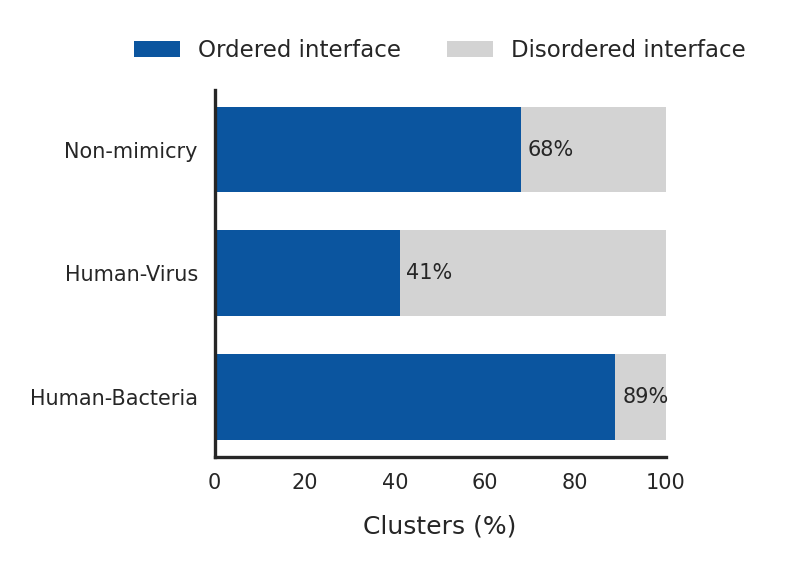

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define cluster groups
groups = {
    "Human-Bacteria": mimicry_clusters_bacteria_refined_non_artifact,
    "Human-Virus": mimicry_clusters_virus_refined_non_artifact,
    "Non-mimicry": non_mimicry_clusters_refined
}

rows = []
ylabels = []

for group_name, cluster_ids in groups.items():
    tmp = cluster_summary[cluster_summary["intcluster"].isin(cluster_ids)].copy()
    tmp = tmp[tmp["top_discat"] != "Unannotated"]
    ordered = (tmp["top_discat"] == "Order-order").sum()
    disordered = ((tmp["top_discat"] == "Disorder-order") | (tmp["top_discat"] == "Disorder-disorder")).sum()
    rows.append({"Ordered interface": ordered, "Disordered interface": disordered})
    ylabels.append(group_name)

# Convert to percentage
discat_summary = pd.DataFrame(rows, index=ylabels)
discat_pct = (discat_summary.div(discat_summary.sum(axis=1), axis=0) * 100)

# Colors
colors = {"Ordered interface": "#0b559f", "Disordered interface": "#d3d3d3"}
order = ["Ordered interface", "Disordered interface"]

# Plot
sns.set_style("white")
fig, ax = plt.subplots(figsize=(2.5,2), dpi=300)

# y positions controlling distance between bars
y_pos = np.array([0, 0.65, 1.30])
left = np.zeros(len(discat_pct))

for category in order:
    values = discat_pct[category].values
    ax.barh(
        y_pos,
        values,
        left=left,
        color=colors[category],
        edgecolor="None",
        linewidth=0.4,
        height=0.45,
        label=category
    )
    left += values

# Percentage labels for ordered interface
for i, pct in enumerate(discat_pct["Ordered interface"]):
    ax.text(
        pct + 1.5,          # just outside the blue segment
        y_pos[i],
        f"{pct:.0f}%",
        va="center",
        ha="left",
        fontsize=5
    )

# Formatting
ax.set_xlim(0, 100)
ax.set_yticks(y_pos)
ax.set_yticklabels(discat_pct.index, fontsize=6,)
ax.set_xlabel("Clusters (%)", fontsize=6, labelpad=5)
ax.set_ylabel("")
ax.tick_params(axis="both", labelsize=5, pad=0.5)
ax.grid(False)

# remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# legend
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,             
    frameon=False,
    fontsize=5.5
)

plt.tight_layout()
plt.savefig("Mimicry_clusters_order_disorder_if_dis.svg", bbox_inches="tight")
plt.show()

In [30]:
results = []

for g1, g2 in combinations(discat_summary.index, 2):

    table = np.array([
        discat_summary.loc[g1],
        discat_summary.loc[g2]
    ])

    oddsratio, p = fisher_exact(table, alternative="two-sided")

    results.append({
        "Comparison": f"{g1} vs {g2}",
        f"{g1} ordered": table[0, 0],
        f"{g1} disordered": table[0, 1],
        f"{g2} ordered": table[1, 0],
        f"{g2} disordered": table[1, 1],
        "Odds ratio": oddsratio,
        "P-value": p
    })

results = pd.DataFrame(results)

results["FDR"] = multipletests(
    results["P-value"],
    method="fdr_bh"
)[1]

print(results.to_markdown(index=False))

| Comparison                    |   Human-Bacteria ordered |   Human-Bacteria disordered |   Human-Virus ordered |   Human-Virus disordered |   Odds ratio |     P-value |   Non-mimicry ordered |   Non-mimicry disordered |        FDR |
|:------------------------------|-------------------------:|----------------------------:|----------------------:|-------------------------:|-------------:|------------:|----------------------:|-------------------------:|-----------:|
| Human-Bacteria vs Human-Virus |                        8 |                           1 |                    16 |                       23 |    11.5      | 0.0226089   |                   nan |                      nan | 0.0339134  |
| Human-Bacteria vs Non-mimicry |                        8 |                           1 |                   nan |                      nan |     3.76256  | 0.285004    |                   438 |                      206 | 0.285004   |
| Human-Virus vs Non-mimicry    |                      nan |

## Pfam Similarity : HB and HV Mimicry Clusters

In [ ]:
import pandas as pd
import numpy as np


# 1. Extract human Pfam annotation from an interface
def get_human_pfam(row):

    pfams = []

    # human chain 0
    if row["tax_id_0"] == 9606:
        if pd.notna(row["pfam_0"]) and str(row["pfam_0"]).strip() != "": pfams.extend(str(row["pfam_0"]).split(","))

    # human chain 1
    if row["tax_id_1"] == 9606:
        if pd.notna(row["pfam_1"]) and str(row["pfam_1"]).strip() != "": pfams.extend(str(row["pfam_1"]).split(","))

    return list(set([x.strip() for x in pfams if x.strip() != ""]))


# 2. Compare Pfam sets
def compare_pfam_sets(pathogen_pfam, hh_pfam):
    """
    Compare all Pfam families.
    Returns:
        Same Pfam
        Different Pfam
    """
    common = sorted(set(pathogen_pfam).intersection(set(hh_pfam)))

    if len(common) > 0:
        return ("Same Pfam", (common[0], common[0]))

    return ("Different Pfam", None)


# 3. Annotate one mimicry cluster
def annotate_pfam_mimicry_cluster(df_cluster):

    # Human-human interfaces
    hh = df_cluster[df_cluster["human-human"] == 1].copy()
    hh_pfams = []
    hh_with_pfam = 0
    hh_without_pfam = 0
    hh_with_matching_pfam = 0

    for _, row in hh.iterrows():

        tmp = get_human_pfam(row)

        if len(tmp) > 0:
            hh_with_pfam += 1
            hh_pfams.extend(tmp)

        else:
            hh_without_pfam += 1

    hh_pfams = list(set(hh_pfams))


    # Human-pathogen interfaces
    hp = df_cluster[df_cluster["human-pathogen"] == 1].copy()
    hp_pfams = []
    hp_with_pfam = 0
    hp_without_pfam = 0
    hp_with_matching_pfam = 0


    for _, row in hp.iterrows():

        tmp = get_human_pfam(row)

        if len(tmp) > 0:
            hp_with_pfam += 1
            hp_pfams.extend(tmp)

        else:
            hp_without_pfam += 1

    hp_pfams = list(set(hp_pfams))


    # Result container
    result = {
        "same_pfam_same_interface": "No",
        "different_pfam_same_interface": "No",
        "best_pfam_match": None,
        "pfam_annotation_status": "Available",
        "n_human_pathogen_interfaces": len(hp),
        "n_human_human_interfaces": len(hh),
        "human_pathogen_interfaces_with_pfam": hp_with_pfam,
        "human_pathogen_interfaces_missing_pfam": hp_without_pfam,
        "human_human_interfaces_with_pfam": hh_with_pfam,
        "human_human_interfaces_missing_pfam": hh_without_pfam,

        # number of unique Pfam families
        "n_human_pathogen_pfams": len(hp_pfams),
        "n_human_human_pfams": len(hh_pfams),

        # NEW: interface-level Pfam counts
        "human_pathogen_interfaces_with_matching_pfam": 0,
        "human_human_interfaces_with_matching_pfam": 0
    }

    # Missing annotation handling
    if len(hp_pfams) == 0 and len(hh_pfams) == 0:
        result["pfam_annotation_status"] = ("HP and HH annotation unavailable")
        return pd.Series(result)

    if len(hp_pfams) == 0:
        result["pfam_annotation_status"] = ("HP annotation unavailable")
        return pd.Series(result)

    if len(hh_pfams) == 0:
        result["pfam_annotation_status"] = ("HH annotation unavailable")
        return pd.Series(result)

    # Compare cluster-level Pfam sets
    similarity, pair = compare_pfam_sets(hp_pfams, hh_pfams)
    result["best_pfam_match"] = pair

    if similarity == "Same Pfam":
        result["same_pfam_same_interface"] = "Yes"

        # Count individual interfaces containing matching Pfam
        for _, row in hp.iterrows():
            hp_interface_pfams = get_human_pfam(row)

            if len(set(hp_interface_pfams).intersection(set(hh_pfams))) > 0:
                result["human_pathogen_interfaces_with_matching_pfam"] += 1

        for _, row in hh.iterrows():

            hh_interface_pfams = get_human_pfam(row)

            if len(set(hh_interface_pfams).intersection(set(hp_pfams))) > 0:
                result["human_human_interfaces_with_matching_pfam"] += 1

    else:
        result["different_pfam_same_interface"] = "Yes"

    return pd.Series(result)


# 4. Human-bacteria mimicry clusters
temp_bacteria = temp_dfhb[temp_dfhb["intcluster"].isin(mimicry_clusters_bacteria_refined)].copy()
cluster_annotations_pfam_bacteria = (temp_bacteria.groupby("intcluster").apply(annotate_pfam_mimicry_cluster).reset_index())
cluster_annotations_pfam_bacteria.to_csv("Pfam_similarity_HB_clusters.csv", index=False)

# 5. Human-virus mimicry clusters
temp_virus = temp_dfhv[temp_dfhv["intcluster"].isin(mimicry_clusters_virus_refined)].copy()
cluster_annotations_pfam_virus = (temp_virus.groupby("intcluster").apply(annotate_pfam_mimicry_cluster).reset_index())
cluster_annotations_pfam_virus.to_csv("Pfam_similarity_HV_clusters.csv", index=False)

/tmp/ipykernel_776244/1241178921.py:147: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_annotations_pfam_bacteria = (temp_bacteria.groupby("intcluster").apply(annotate_pfam_mimicry_cluster).reset_index())
/tmp/ipykernel_776244/1241178921.py:152: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cluster_annotations_pfam_virus = (temp_virus.groupby("intcluster").apply(annotate_pfam_mimicry_cluster).reset_index())


## Plot Pathogen Mimicry Clusters

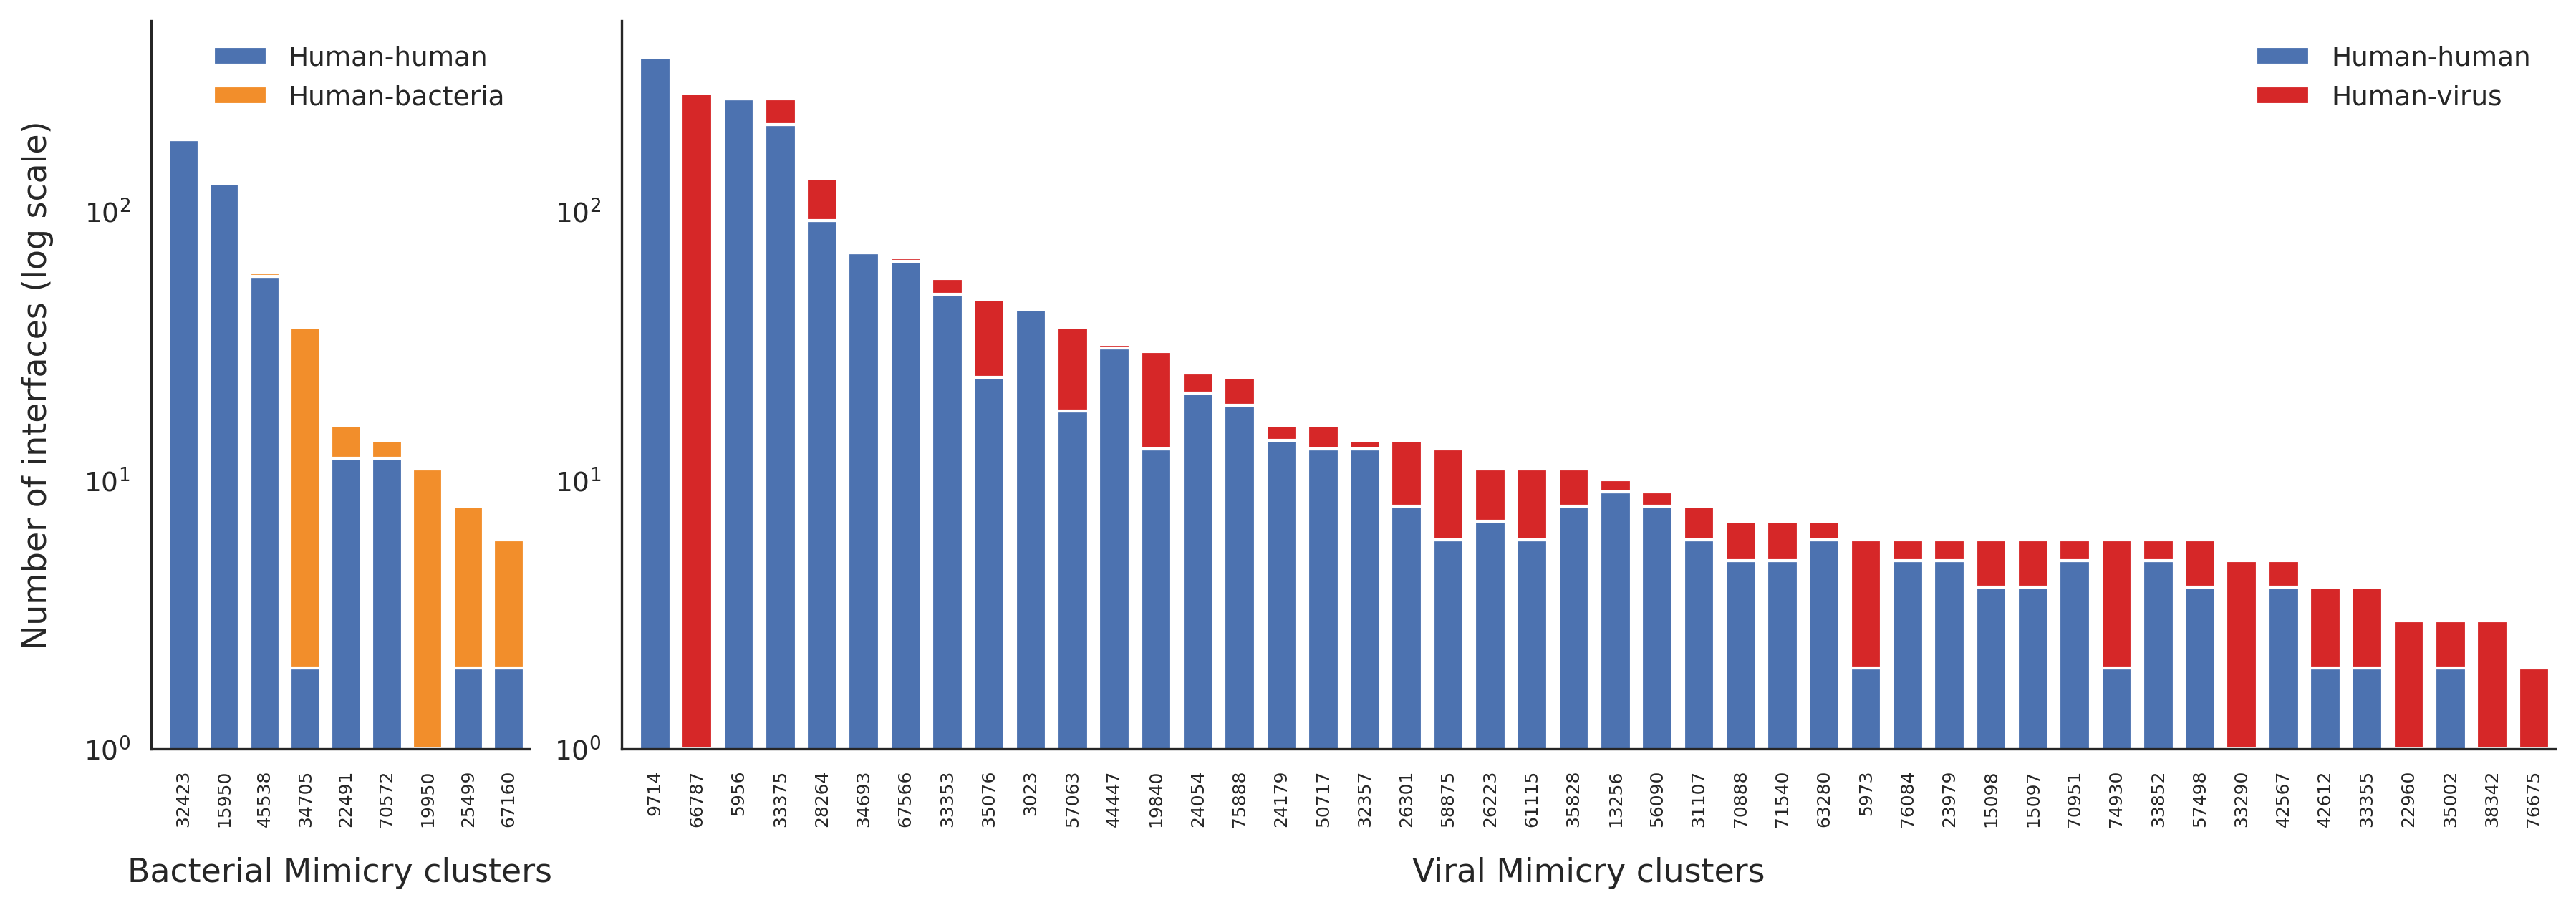

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to build cluster interface table
def build_cluster_interface_table(cluster_list, cluster_summary, interface_df,):

    # Total cluster size
    cluster_info = (cluster_summary[cluster_summary["intcluster"].isin(cluster_list)][["intcluster", "cluster_size"]].drop_duplicates())

    # HH and HP interface counts
    interface_count = (interface_df[interface_df["intcluster"].isin(cluster_list)].groupby("intcluster")["human-human"].agg(HH=lambda x: (x == 1).sum(), HP=lambda x: (x == 0).sum()).reset_index())
    out = cluster_info.merge(interface_count, on="intcluster", how="left")
    out = out.fillna(0)
    out["HH"] = out["HH"].astype(int)
    out["HP"] = out["HP"].astype(int)
    return out

# Build bacterial and viral tables
bacteria_clusters = build_cluster_interface_table(mimicry_clusters_bacteria_refined_non_artifact, cluster_summary, temp_dfhb)
virus_clusters = build_cluster_interface_table(mimicry_clusters_virus_refined_non_artifact, cluster_summary, temp_dfhv)

# Sort by plotted interface count
bacteria_clusters["total_interfaces"] = (bacteria_clusters["HH"] + bacteria_clusters["HP"])
virus_clusters["total_interfaces"] = (virus_clusters["HH"] + virus_clusters["HP"])
bacteria_clusters = (bacteria_clusters.sort_values("total_interfaces", ascending=False).reset_index(drop=True))
virus_clusters = (virus_clusters.sort_values("total_interfaces", ascending=False).reset_index(drop=True))

# Plot
sns.set_style("white")

# Width of each panel proportional to the number of clusters
fig = plt.figure(figsize=(0.2625 * (len(bacteria_clusters) +len(virus_clusters)), 4.4), dpi=300)
gs = fig.add_gridspec(1, 2, width_ratios=[len(bacteria_clusters), len(virus_clusters)], wspace=0.08)
ax_bacteria = fig.add_subplot(gs[0])
ax_virus = fig.add_subplot(gs[1], sharey=ax_bacteria)
axes = [ax_bacteria, ax_virus]
bar_width = 0.75

# Bacterial mimicry clusters
ax = axes[0]
x = np.arange(len(bacteria_clusters))
ax.bar(
    x,
    bacteria_clusters["HH"],
    width=bar_width,
    color="#4C72B0",
    label="Human-human"
)

ax.bar(x, bacteria_clusters["HP"], bottom=bacteria_clusters["HH"], width=bar_width, color="#F28E2B", label="Human-bacteria")

# Remove the empty space at the beginning/end
ax.set_xlim(-0.8, len(bacteria_clusters)-0.5)
ax.margins(x=0)
ax.set_xlabel("Bacterial Mimicry clusters", fontsize=11, labelpad=10)
ax.set_ylabel("Number of interfaces (log scale)", fontsize=11, labelpad=10)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(bacteria_clusters["intcluster"], rotation=90, fontsize=6)
ax.tick_params(axis="y", labelsize=9)
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Viral mimicry clusters
ax = axes[1]
x = np.arange(len(virus_clusters))
ax.bar(x, virus_clusters["HH"], width=bar_width, color="#4C72B0", label="Human-human")
ax.bar(x, virus_clusters["HP"], bottom=virus_clusters["HH"], width=bar_width, color="#D62728", label="Human-virus")
ax.set_xlim(-0.8, len(virus_clusters)-0.5) # Remove the empty space at the beginning/end
ax.margins(x=0)
ax.set_xlabel("Viral Mimicry clusters", fontsize=11, labelpad=10)
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(virus_clusters["intcluster"],rotation=90, fontsize=6)
ax.tick_params(axis="y", labelsize=9)
ax.legend(frameon=False, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.subplots_adjust(wspace=0.08) # Small gap between panels

plt.savefig("Mimicry_clusters_bar_graph.svg")
plt.show()

## Mimicry Cluster Network 

In [33]:
import pandas as pd

# Specify mimicry cluster
cluster_id = 28264          # <-- Change cluster ID

# Select interfaces belonging to the cluster
cluster_df = temp_dfhv[temp_dfhv["intcluster"] == cluster_id].copy()

# Build interaction table
interaction_rows = []

# Human-Human interactions
hh_df = cluster_df[cluster_df["human-human"] == 1]

for _, row in hh_df.iterrows():

    if pd.isna(row["human_human_genes"]):
        continue

    genes = str(row["human_human_genes"]).strip().split("-")

    if len(genes) != 2:
        continue

    interaction_rows.append({"protein1": genes[0].strip(), "protein2": genes[1].strip(), "if_type": "HH"})


# Human-Virus interactions
hv_df = cluster_df[(cluster_df["human-pathogen"] == 1) & (cluster_df["pathogen_type"] == "Virus")]

for _, row in hv_df.iterrows():

    if (pd.isna(row["gene_human"]) or pd.isna(row["gene_pathogen"])):
        continue

    interaction_rows.append({"protein1": str(row["gene_human"]).strip(), "protein2": str(row["gene_pathogen"]).strip(), "if_type": "HV"})

interaction_df = (pd.DataFrame(interaction_rows).drop_duplicates().sort_values(["if_type", "protein1", "protein2"]).reset_index(drop=True))


# Build pathogen annotation table
pathogen_df = (hv_df[["gene_pathogen", "organism_pathogen"]].rename(columns={"gene_pathogen": "pathogen_gene", "organism_pathogen": "species"}).dropna().drop_duplicates().sort_values(["species", "pathogen_gene"]).reset_index(drop=True))

# Save CSV files
interaction_file = f"{cluster_id}_HH_HV_network.csv"
pathogen_file   = f"{cluster_id}_pathogen_species.csv"

interaction_df.to_csv(interaction_file, index=False)
pathogen_df.to_csv(pathogen_file, index=False)

print(f"Saved: {interaction_file}")
print(f"Saved: {pathogen_file}")

Saved: 28264_HH_HV_network.csv
Saved: 28264_pathogen_species.csv


In [34]:
import pandas as pd

# Specify mimicry cluster
cluster_id = 64762      # <-- Change cluster ID

# Select interfaces belonging to the cluster

cluster_df = temp_dfvb[temp_dfvb["intcluster"] == cluster_id].copy()

# Build interaction table
interaction_rows = []

# Human-Human interactions
hh_df = cluster_df[cluster_df["human-human"] == 1]

for _, row in hh_df.iterrows():

    if pd.isna(row["human_human_genes"]):
        continue

    genes = str(row["human_human_genes"]).strip().split("-")

    if len(genes) != 2:
        continue

    interaction_rows.append({
        "protein1": genes[0].strip(),
        "protein2": genes[1].strip(),
        "if_type": "HH"
    })

# Human-Virus interactions
hv_df = cluster_df[(cluster_df["human-pathogen"] == 1) & (cluster_df["pathogen_type"] == "Virus")]

for _, row in hv_df.iterrows():

    if (pd.isna(row["gene_human"]) or pd.isna(row["gene_pathogen"])):
        continue

    interaction_rows.append({"protein1": str(row["gene_human"]).strip(), "protein2": str(row["gene_pathogen"]).strip(), "if_type": "HV"})

# Human-Bacteria interactions
hb_df = cluster_df[(cluster_df["human-pathogen"] == 1) & (cluster_df["pathogen_type"] == "Bacteria")]

for _, row in hb_df.iterrows():

    if (pd.isna(row["gene_human"]) or pd.isna(row["gene_pathogen"])):
        continue

    interaction_rows.append({"protein1": str(row["gene_human"]).strip(), "protein2": str(row["gene_pathogen"]).strip(), "if_type": "HB"})


# Interaction table
interaction_df = (pd.DataFrame(interaction_rows).drop_duplicates().sort_values(["if_type", "protein1", "protein2"]).reset_index(drop=True))

# Pathogen annotation table
pathogen_df = (
    pd.concat([hv_df[["gene_pathogen", "organism_pathogen"]], hb_df[["gene_pathogen", "organism_pathogen"]]], ignore_index=True)
    .rename(columns={"gene_pathogen": "pathogen_gene", "organism_pathogen": "species"})
    .dropna().drop_duplicates().sort_values(["species", "pathogen_gene"]).reset_index(drop=True)
)


# Save CSV files
interaction_file = (f"{cluster_id}_HH_HV_HB_network.csv")
pathogen_file = (f"{cluster_id}_pathogen_species.csv")
interaction_df.to_csv(interaction_file, index=False)
pathogen_df.to_csv(pathogen_file, index=False)

print(f"Saved: {interaction_file}")
print(f"Saved: {pathogen_file}")

Saved: 64762_HH_HV_HB_network.csv
Saved: 64762_pathogen_species.csv
